Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU8proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU8proj.ipynb"

# Unit 8 Project: Writing a BARTical

**Task**:

Two parts:

1. Propose a data set that's compatible with a pymc_bart model. I must approve your submission before you move on to part 2.

2. Create, analyze, and present BART model, using pymc_bart within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is)
  - You must argue why your variable selection is justified. You may use either a theoretical or numerical argument. Additionally, you must comment on any potential interactions between your predictor variables.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [15]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')
print(list(counties))

counties = counties[[ 'edu/some-college', 'edu/bachelors+', 'poverty-rate','life-expectancy','bls/2016/labor_force', 'bls/2016/employed', 'bls/2016/unemployed']]
counties

['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)', 'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow', 'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr', 'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes', 'race/non_hispanic_white_alone_male', 'race/non_hispanic_white_alone_female', 'race/black_alone_male', 'race/black_alone_female', 'race/asian_alone_male', 'race/asian_alone_female', 'race/hispanic_male', 'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14', 'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39', 'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64', 'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+', 'male', 'female', 'population/2010', 'population/2011', 'population/2012', 'population/2013', 'population/2014', 'population/2015', 'population/2016', 'population/2017', 'population/2018', 'population/2019', 'deaths/suicides', 'deaths/firearm suicides', 'deaths/homicides', 'deaths/vehicle', 'bls/2004/labor_f

,edu/some-college,edu/bachelors+,poverty-rate,life-expectancy,bls/2016/labor_force,bls/2016/employed,bls/2016/unemployed
0,29.5,23.8,8.9,81.20,4711.0,4575.0,136.0
1,32.6,39.5,10.7,80.46,168830.0,164151.0,4679.0
2,37.0,20.9,11.2,80.12,2363.0,2295.0,68.0
3,39.3,20.5,11.1,79.24,4611.0,4478.0,133.0
4,39.9,23.5,10.0,79.86,4923.0,4800.0,123.0
...,...,...,...,...,...,...,...
3137,26.0,46.1,8.0,81.14,68898.0,65630.0,3268.0
3138,25.8,29.0,14.0,79.26,323192.0,305351.0,17841.0
3139,22.5,49.0,6.8,81.16,26132.0,24924.0,1208.0
3140,23.8,48.1,8.5,81.15,44233.0,42154.0,2079.0


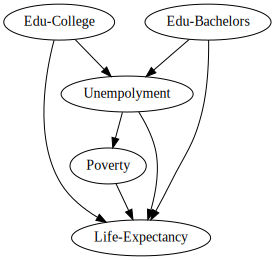

In [60]:

octodag = gv.Digraph(name="OctoDAG")

octodag.node('T','Edu-College')
octodag.node('U','Edu-Bachelors')
##octodag.node('W','precipitation')
octodag.node('K','Poverty')
octodag.node('S','Life-Expectancy')
octodag.node('L','Unempolyment')

octodag.edges(['TL','UL','LK','KS','TS','US','LS'])

octodag

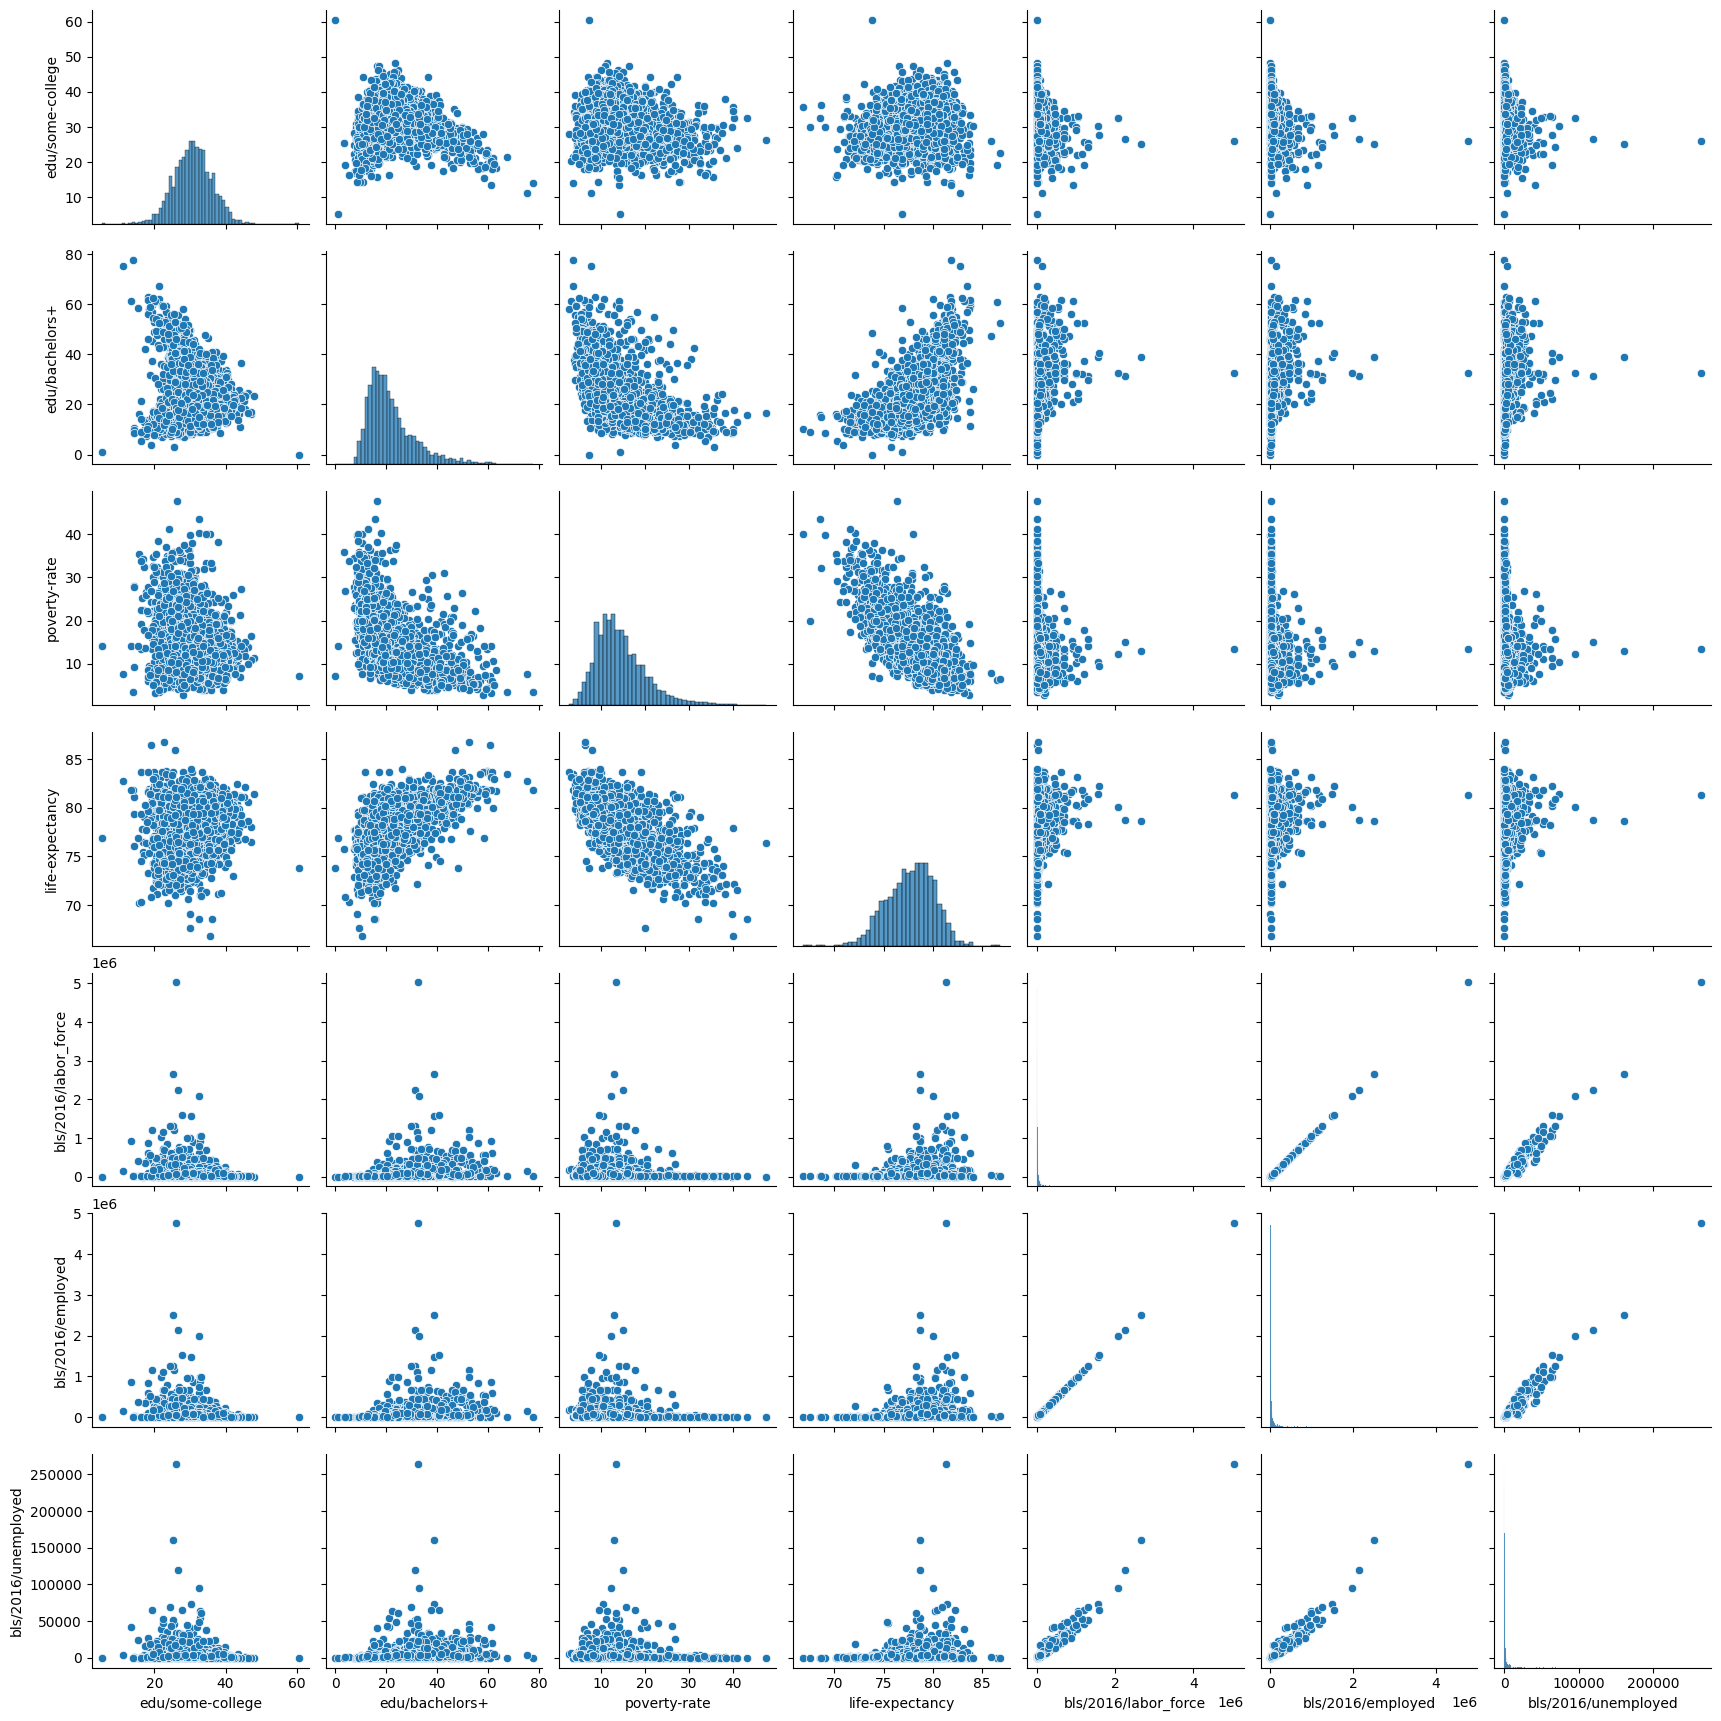

In [16]:
sns.pairplot(counties)

In [40]:
X = counties[['edu/bachelors+', 'edu/some-college', 'poverty-rate','bls/2016/unemployed']]
Y = counties["life-expectancy"]

In [ ]:

with pm.Model() as model_counties:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties, model=model_counties, extend_inferencedata=True)


(1.0, 250.0)

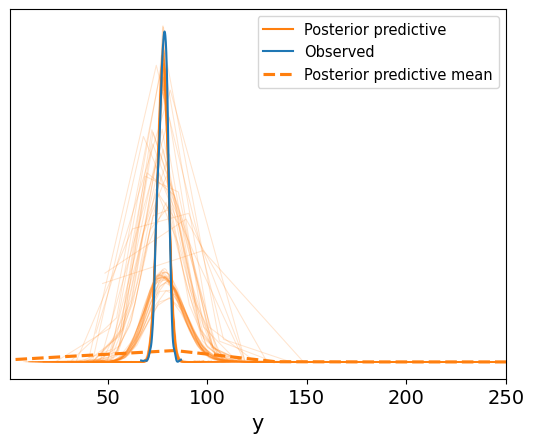

In [62]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax.set_xlim(1,250)

In [50]:


posterior_mean = idata_counties.posterior["μ"]

μ_hdi = az.hdi(ary=idata_counties, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_counties, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


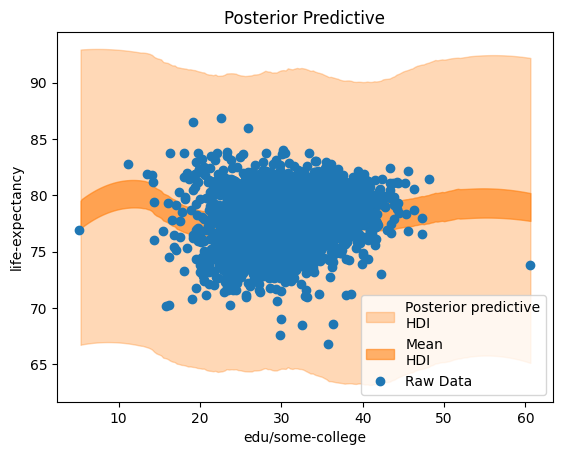

In [52]:
idx = np.argsort(X['edu/some-college'])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X['edu/some-college'],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior predictive\nHDI"},
)

az.plot_hdi(
    x=X['edu/some-college'],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\nHDI"},
)
ax.plot(counties['edu/some-college'], counties["life-expectancy"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="edu/some-college",
    ylabel="life-expectancy",
);

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


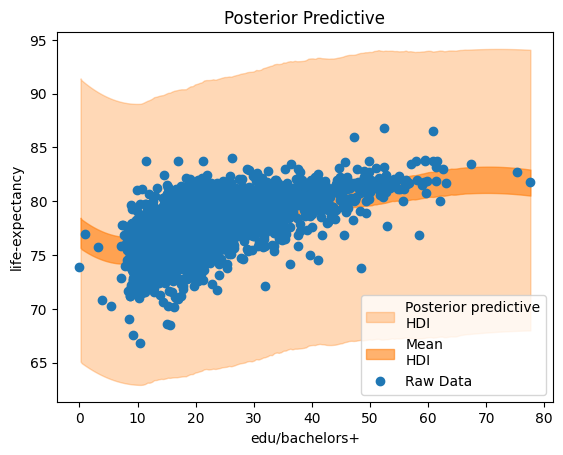

In [53]:
idx = np.argsort(X['edu/bachelors+'])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X['edu/bachelors+'],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior predictive\nHDI"},
)

az.plot_hdi(
    x=X['edu/bachelors+'],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\nHDI"},
)
ax.plot(counties['edu/bachelors+'], counties["life-expectancy"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="edu/bachelors+",
    ylabel="life-expectancy",
);

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


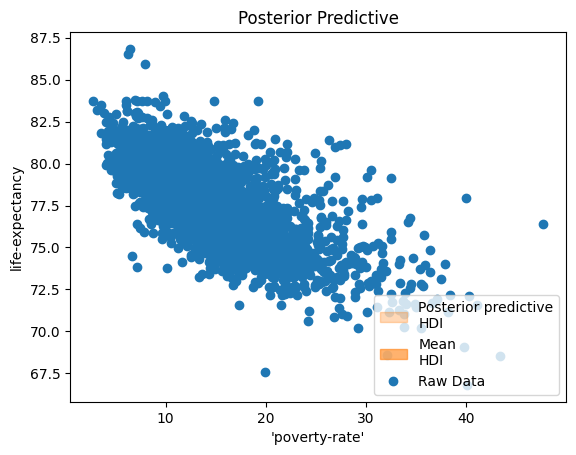

In [54]:
idx = np.argsort(X['poverty-rate'])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X['poverty-rate'],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior predictive\nHDI"},
)

az.plot_hdi(
    x=X['poverty-rate'],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\nHDI"},
)
ax.plot(counties['poverty-rate'], counties["life-expectancy"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="'poverty-rate'",
    ylabel="life-expectancy",
);

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


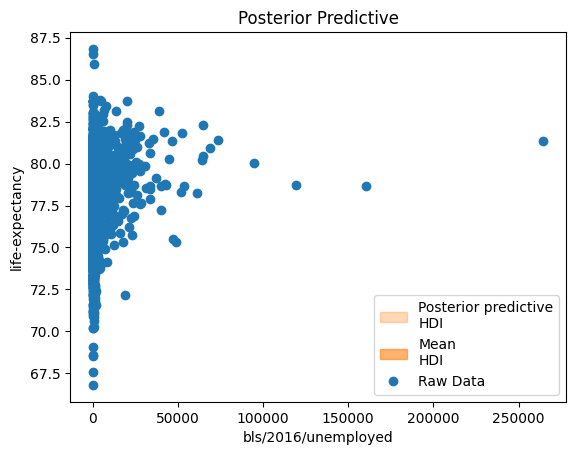

In [55]:
idx = np.argsort(X['bls/2016/unemployed'])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X['bls/2016/unemployed'],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior predictive\nHDI"},
)

az.plot_hdi(
    x=X['bls/2016/unemployed'],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\nHDI"},
)
ax.plot(counties['bls/2016/unemployed'], counties["life-expectancy"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="bls/2016/unemployed",
    ylabel="life-expectancy",
);

<Axes: ylabel='R²'>

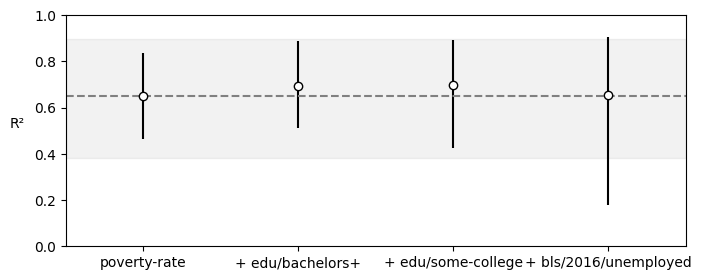

In [56]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X)
pmb.plot_variable_importance(vi_counties)


In conclusion, the variable that has the most impact on life expectancy is education- whether at a college or bachleor rate.